In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append(f"./../")
from src import MCRX, Expression

from sympy import symbols
import numpy as np

In [3]:
x0, x2 = symbols(r"x_0, x_2", Latex=True)
#expr = ~x0 & ~x1 | ~x0 & x1 | x0 & ~x1
#expr = ~x0 & ~x1 | ~x0 & x1 | x0 & ~x1 | x0 & x1
#expr = ~x0 & ~x1 |  x0 & ~x1
#expr = ~x0 & ~x1 |  ~x0 & x1

expr = x0 & ~x2 | x0 & x2
expr = Expression(expr)

print('The Expression:')
expr.expr

The Expression:


(x_0 & x_2) | (x_0 & ~x_2)

In [4]:
print('The Expression (simplified):')
expr.simplify().expr

The Expression (simplified):


x_0

In [5]:
print(expr.simplify().expr == x0)

True


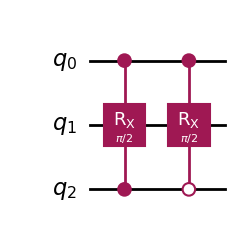

In [6]:
target = 1
n_qubits = 3
rot_angle = np.pi / 2
expr = x0 & ~x2 | x0 & x2
mcrx = MCRX(n_qubits, expr, target, rot_angle)
mcrx.qc.draw("mpl")

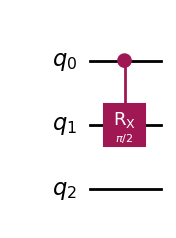

In [7]:
mcrx = mcrx.simplify()
mcrx.qc.draw("mpl")

In [8]:
x1, x2, x3, x4 = symbols(r"x_1, x_2, x_3, x_4", Latex=True)
expr = ~x1 & ~x2 & ~x3 & ~x4 | ~x1 & x2 & ~x3 & ~x4 | ~x1 & ~x2 & ~x3 & x4
expr

(x_2 & ~x_1 & ~x_3 & ~x_4) | (x_4 & ~x_1 & ~x_2 & ~x_3) | (~x_1 & ~x_2 & ~x_3 & ~x_4)

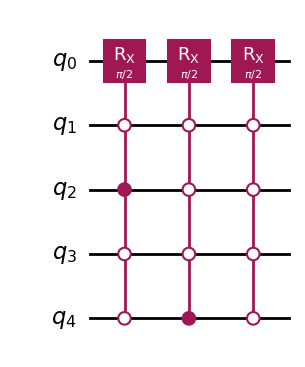

In [9]:
target = 0
n_qubits = 5
rot_angle = np.pi / 2

mcrx = MCRX(n_qubits, expr, target, rot_angle)
mcrx.qc.draw("mpl")

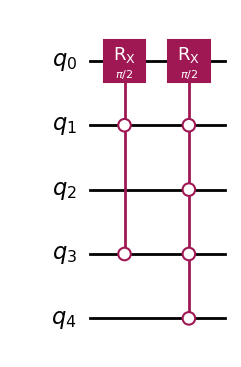

In [10]:
mcrx = mcrx.simplify()
mcrx.qc.draw("mpl")

In [11]:
from sympy import simplify

mcrx.expr == ~x1 & ~x2 & ~x3 & ~x4 | ~x1 & ~x3

False

In [12]:
x0, x1, x2, x3, x4,  x5, x6 = symbols(r"x_0, x_1, x_2, x_3, x_4,x_5, x_6", Latex=True)
expr = ~x0 & ~x1 & ~x2 & ~x4 & ~x5 & ~x6 | x0 & ~x1 & ~x2 & ~x4 & ~x5 & ~x6 | ~x0 & ~x1 & x2 & ~x4 & ~x5 & ~x6 | ~x0 & ~x1 & ~x2 & x4 & ~x5 & ~x6 | ~x0 & ~x1 & ~x2 & ~x4 & ~x5 & x6 
expr

(x_0 & ~x_1 & ~x_2 & ~x_4 & ~x_5 & ~x_6) | (x_2 & ~x_0 & ~x_1 & ~x_4 & ~x_5 & ~x_6) | (x_4 & ~x_0 & ~x_1 & ~x_2 & ~x_5 & ~x_6) | (x_6 & ~x_0 & ~x_1 & ~x_2 & ~x_4 & ~x_5) | (~x_0 & ~x_1 & ~x_2 & ~x_4 & ~x_5 & ~x_6)

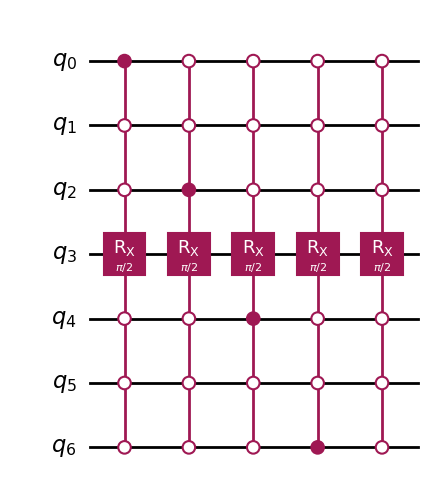

In [13]:
target = 3
n_qubits = 7
rot_angle = np.pi / 2

mcrx = MCRX(n_qubits, expr, target, rot_angle)
mcrx.qc.draw("mpl")

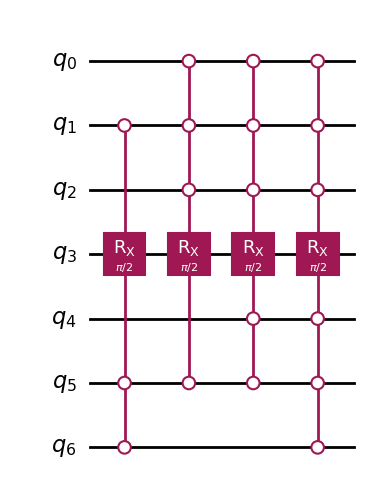

In [14]:
mcrx = mcrx.simplify()
mcrx.qc.draw("mpl")